# Лабораторная работа: обучение многообразий

# PCA

В этом блоке вам предстоит выполнить задания, касающиеся метода главных компонент (`PCA`).

## Теоретическая часть

Пусть на вход подаются центрированные данные
$$
x_i = \begin{pmatrix}
x_{i1} \\ x_{i2} \\ \vdots \\ x_{ip}
\end{pmatrix} \in \mathbb R^{p \times 1}, \quad i \in \{1, \ldots, n\}, \quad \sum\limits_{i = 1}^n x_i = 0.
$$
Пусть также $X$ — матрица размера $n \times p$ — матрица объекты-признаки (внимание: объекты расположены в матрице $X$ по строкам), $W$ – матрица размера $p \times l$ из ортонормированных базисных векторов (их координаты записаны по столбцам) линейного подпространства $\mathbb R^l$ пространства $\mathbb R^p$, в которое мы хотим «вложить» исходные объекты, $Z$ — матрица размера $n \times l$ — матрица координат старых объектов в новом базисе. Мы определили функцию потерь ($l_2$-потери) следующим образом:

$$
L(W) = \|X^T - WZ^T\|^2_F = \sum\limits_{i = 1}^n \|x_i - Wz_i\|^2.
$$

На лекции мы обсудили построение первой главной компоненты, минимизируя выражение

$$
L(W) = \sum\limits_{i = 1}^n\|x_i - w_1z_{i1}\|^2.
$$

При условии, что $w_1^Tw_1 = 1$, мы получили, что

$$
z_{i1} = x_i^Tw_1,
$$

то есть что новая координата есть проекция на $w_1$, и что $w_1$ — собственный вектор выборочной ковариационной матрицы

$$
\Sigma = \frac{1}{n}X^TX,
$$

отвечающей наибольшему собственному значению.



## Задача 1

Вам требуется построить первые две главные компоненты, объяснить сособ их получения, а также их геометрический и статистический смыслы. Для этого:

1.   Составьте минимизируемый функционал.
2.   Докажите, что новые координаты (счеты) — это проекции исходных данных на соотвествующие векторы $w_1$, $w_2$.
3. Докажите, что $w_1$, $w_2$ — это собственные векторы выборочной ковариационной матрицы, отвечающие двум наибольшим собственным значениям, по убыванию, соответственно.
4. Покажите, что статистический смысл упомянутых выше собственных чисел — значение выборочных дисперсий соответствующих (новых) координат.

**Решение:**

1. Составьте минимизируемый функционал.
Для первого направления $w_1$ минимизируем функцию потерь уже была описана на лекции и выше:
$$
L(W) = \sum\limits_{i = 1}^n \|x_i - w_1 z_{i1}\|^2,
$$

Каждая координата независима от других. В этом базисе ковариационная матрица проекций становится диагональной, и это упрощает анализ данных, поскольку дисперсия вдоль каждой новой оси (главной компоненты) не зависит от других осей. Такой подход также помогает в шумоподавлении и выборе значимых компонент, так как в базисе главных компонент можно легко отсеивать компоненты с малой дисперсией (обычно составляющие шум).

Для второго направления $w_2$, ортогонального $w_1$, минимизируем следующую функцию потерь:
$$
L(W) = \sum\limits_{i = 1}^n \|x_i - w_1 z_{i1} - w_2 z_{i2}\|^2,
$$
где
$$
z_{i2} = x_i^T w_2.
$$
Вектор $w_2$ также является собственным вектором матрицы $\Sigma$, но отвечает второму по величине собственному значению, захватывая наибольшую оставшуюся дисперсию данных в направлении, ортогональном $w_1$.

2. Докажите, что новые координаты (счеты) — это проекции исходных данных на соотвествующие векторы  $𝑤_1$ , $𝑤_2$ .


При нахождении первого главного компонента $w_1$ мы минимизировали функцию потерь:
$$
  L(W) = \sum\limits_{i=1}^n \|x_i - w_1 z_{i1}\|^2,
$$
где $z_{i1} = x_i^T w_1$ — проекция вектора $x_i$ на направление $w_1$. Это направление соответствует максимальной дисперсии данных и максимизирует расстояние между проекциями, то есть счётами $z_{i1}$.

$$
  L(W) = \sum\limits_{i=1}^n \|x_i - w_1 z_{i1}\|^2 = \sum\limits_{i=1}^n \|x_i - w_1 z_{i1}\|^T\|x_i - w_1 z_{i1}\| = \sum\limits_{i=1}^n(x-y)^T(x-y)=\sum\limits_{i=1}^n(xx^T-2x^Ty+y^Ty),
$$

Подставим:
$$
  L(W) = \sum\limits_{i=1}^n(x_ix_i^T-2z_{i1}(x_i^Tw_1)+z_{i1}^2(w_1^Tw_1)),
$$

Возьмем производную по $z_{i1}$:

$$
  -2(x_i^Tw)+2z_{i1}=0 (минимизируем)
$$

Тогда:
$$
  (x_i^Tw)=z_{i1}
$$

Для двух получается:
$$
  L(W) = \sum\limits_{i=1}^n \|x_i - (w_1 z_{i1}+w_2 z_{i2})\|^2 = \sum\limits_{i=1}^n ||x_i||^2-2z_{i1}(x_iw_1)^T+z_{i1}^2-2z_{i2}(x_i^Tw_2)+z_{i2}^2
$$

Смотрим на вторую, так как первую рассмотрели выше:
Возьмем производную по $z_{i2}$:

$$
  -2(x_i^Tw)+2z_{i2}=0
$$
Тогда:
$$
  (x_i^Tw)=z_{i2}
$$

3. Докажите, что  𝑤1 ,  𝑤2  — это собственные векторы выборочной ковариационной матрицы, отвечающие двум наибольшим собственным значениям, по убыванию, соответственно.

Вектора $w_1$ и $w_2$ будут собственными векторами, если будут удовлетворять условию:

$$
\Sigma w_i = \lambda_i w_i, \quad \text{где} \quad \lambda_i \text{ — собственное значение, соответствующее собственному вектору } w_i.
$$


Ковариационная матрица $\Sigma$ для центрированных данных $X \in \mathbb{R}^{n \times p}$ имеет вид:

$$
\Sigma = \frac{1}{n} X^T X,
$$

где $X$ — это матрица данных, строки которой — это объекты $x_1, x_2, \dots, x_n$. Ковариационная матрица характеризует взаимосвязь между признаками, то есть степень коррелированности между различными компонентами данных.

Минимизация функции, которую мы описали для первой главной компненты, эквивалентна максимизации дисперсии проекций данных на $w_1$, что даёт следующее условие:

$$
\text{max } w_1^T \Sigma w_1 \quad \text{при условии } \|w_1\| = 1.
$$

Это условие максимизации приводит нас к решению задачи на собственные значения и собственные векторы:

$$
\Sigma w_1 = \lambda_1 w_1,
$$

где $\lambda_1$ — собственное значение, соответствующее собственному вектору $w_1$.

Минимизация функции, которую мы описали для второй главной компненты,  функции эквивалентна максимизации оставшейся дисперсии данных, что даёт следующее условие:

$$
\text{max } w_2^T \Sigma w_2 \quad \text{при условии } \|w_2\| = 1 \text{ и } w_2^T w_1 = 0.
$$

Это условие также сводится к задаче на собственные значения и собственные векторы, при этом $w_2$ соответствует второму по величине собственному значению $\lambda_2$:

$$
\Sigma w_2 = \lambda_2 w_2,
$$

где $\lambda_2$ — собственное значение, соответствующее собственному вектору $w_2$.

4. Покажите, что статистический смысл упомянутых выше собственных чисел — значение выборочных дисперсий соответствующих (новых) координат.


После применения метода главных компонент (PCA) данные проектируются на новые оси, определяемые собственными векторами ковариационной матрицы. Эти новые оси называются главными компонентами, и каждая главная компонента является собственным вектором ковариационной матрицы $\Sigma$.

Проекции данных на новые оси задаются следующими выражениями:

$$
z_{i1} = x_i^T w_1 \quad \text{и} \quad z_{i2} = x_i^T w_2,
$$

где $z_{i1}$ и $z_{i2}$ — новые координаты для точки $x_i$ в пространстве главных компонент.

Ковариационная матрица $\Sigma$ описывает взаимосвязь между признаками в исходных данных. После выполнения PCA матрица ковариации данных в новом базисе (вдоль осей главных компонент) становится диагональной:

$$
\Sigma_{\text{new}} = \begin{pmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{pmatrix},
$$

где $\lambda_1$ и $\lambda_2$ — это собственные значения ковариационной матрицы $\Sigma$. Эти значения описывают дисперсии данных вдоль новых осей.


Собственные значения ковариационной матрицы $\Sigma$, такие как $\lambda_1$ и $\lambda_2$, показывают дисперсию данных вдоль соответствующих направлений, определённых собственными векторами $w_1$ и $w_2$. То есть, собственные значения отражают, насколько сильно данные изменяются вдоль каждой из главных компонент.


Таким образом, статистический смысл собственных чисел заключается в том, что они представляют собой выборочные дисперсии данных вдоль новых координат (главных компонент).


## Задача 2

Предыдущий подход хорошо работает в случае, когда $n$ сильно больше $p$. В противном случае разумнее рассматривать тоже симметричную матрицу $XX^T$. Ваша задача, взяв конкретную матрицу $X$ (скажем, размера $3 \times 3$, но можно и в общем виде), показать, что

1.   Существует ортогональная матрица $U$, что

$$
U^TXX^TU = \Lambda,
$$

где последняя матрица — диагональная.

2.   Верно равенство

$$
XX^TU = U \Lambda,
$$

а значит и равенство

$$
X^TXX^TU = X^TU \Lambda,
$$

откуда

$$
(X^TX)(X^TU) = X^TU \Lambda
$$

и $X^TU$ — матрица из собственных векторов для $X^TX$.

3. Показать, что столбцы матрицы $X^TU$ ортогональны, но не ортонормированы.

4. Найти нормы столбцов $X^TU$, привести преобразование к ортогональному. Получить аналог `PCA`.

5. Показать численно (на конкретной матрице) с использованием, например, `numpy`.

**Решение:**

1.
Матрица $X X^T$ является симметричной, так как:

$$
(X X^T)^T = X (X^T)^T = X X^T.
$$

Это свойство матрицы $X X^T$ позволяет применить к ней теорему о диагонализации симметричной матрицы.

Теорема утверждает, что любая симметричная матрица может быть диагонализирована с помощью ортогональной матрицы. То есть существует ортогональная матрица $U$, такая что:

$$
U^T (X X^T) U = \Lambda,
$$

где $\Lambda$ — диагональная матрица. Это диагонализация матрицы $X X^T$.


Для того, чтобы найти матрицу $U$, необходимо вычислить собственные векторы и собственные значения матрицы $X X^T$. Собственные векторы будут формировать столбцы ортогональной матрицы $U$, а соответствующие собственные значения будут лежать на диагонали матрицы $\Lambda$.

Возмем матрицу $X$ и вычислим матрицу $X X^T$. Для этого умножим $X$ на её транспонированную матрицу $X^T$

$$
X = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3 \end{pmatrix},
$$

$$
X^T = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3 \end{pmatrix},
$$


$$
X X^T = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 4 & 0 \\ 0 & 0 & 9 \end{pmatrix}.
$$


Теперь нужно найти собственные значения и собственные векторы матрицы $X X^T$. Для этого решим характеристическое уравнение:

$$
\det(X X^T - \lambda I) = 0,
$$

где $I$ — единичная матрица, а $\lambda$ — собственное значение. После решения этого уравнения мы получим собственные значения матрицы $X X^T$.


$$
\lambda_1 = 1, \quad \lambda_2 = 4, \quad \lambda_3 = 9.
$$


Для каждого собственного значения находим собственный вектор, решая систему линейных уравнений:

$$
(X X^T - \lambda I)v = 0.
$$

Решая для каждого $\lambda$, получаем соответствующие собственные векторы. Пусть полученные собственные векторы будут следующими:

$$
v_1 = \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}, \quad v_2 = \begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}, \quad v_3 = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}.
$$


Для того чтобы получить ортогональную матрицу $U$, нужно нормализовать собственные векторы. Но так как они у нас единичные, то уже нормированы

Теперь матрица $U$ будет иметь столбцы, содержащие эти нормализованные собственные векторы:

$$
U = \begin{pmatrix} 1 & 0 & 0 \\
0 & 1 &  0 \\
0 & 0 & 1
\end{pmatrix}.
$$


Теперь мы можем утверждать, что существует ортогональная матрица $U$, такая что:

$$
U^T X X^T U = \Lambda,
$$

где $\Lambda$ — диагональная матрица с собственными значениями $\lambda_1 = 1$, $\lambda_2 = 4 $, и $\lambda_3 = 9$ на диагонали. Матрица $U$ состоит из нормализованных собственных векторов матрицы $X X^T$.

2. Для того, чтобы доказать, что:

$$(X^T X)(X^T U) = X^T U \lambda,$$

Рассчитаем $X^T X$

Для начала вычислим $X^T$, транспонированную матрицу:

$$
X^T = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3 \end{pmatrix},
$$

Теперь вычислим $X^T X$:

$$
X^T X = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 4 & 0 \\ 0 & 0 & 9 \end{pmatrix}
$$

$$
X^T U = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3\end{pmatrix}
$$


Теперь умножим матрицу $X^T X$ на матрицу $X^T U$. Для этого нужно выполнить умножение каждого столбца матрицы $U$ на матрицу $X^T X$.

$$
(X^T X) U = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3\end{pmatrix}
$$



Теперь рассмотрим выражение $(X^T X)(X^T U)$.

$$
(X^T X)(X^T U) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 8 & 0 \\ 0 & 0 & 27\end{pmatrix}
$$

$$
X^T U \lambda = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3\end{pmatrix} \cdot \begin{pmatrix} 1 & 4 & 9 \end{pmatrix} = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 8 & 0 \\ 0 & 0 & 27\end{pmatrix}
$$


Умножение матрицы $ X^T X $ на матрицу $ X^T U $ фактически применяется к собственным векторам, и для каждого столбца матрицы $ U $ мы получаем:

$$
(X^T X)(X^T U) = X^T U \lambda
$$

где $ \lambda_i $ — соответствующее собственное значение.

Таким образом, выражение:

$$
(X^T X)(X^T U) = X^T U \lambda
$$

выполняется

3. Показать, что столбцы матрицы  $X^T U$ ортогональны, но не ортонормированы.

Чтобы проверить  ортогональны ли столбцы матрицы нужно убедиться, что скалярное произведение любых двух столбцов равно нулю


$$
X^T U  = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 3\end{pmatrix}
$$

Скалярное произведение 1 и 2 столбца $ 1 \cdot 0 + 0 \cdot 2 + 0 \cdot 0 = 0 $

Скалярное произведение 1 и 3 столбца $ 1 \cdot 0 + 0 \cdot 0 + 0 \cdot 3 = 0 $

Скалярное произведение 2 и 3 столбца $ 0 \cdot 0 + 2 \cdot 0 + 0 \cdot 3 = 0 $

Так как все скалярные произведения между столбцами равны нулю, значит столбцы ортогональны

Для того что столбцы были ортонормированными, каждый столбец должен быть единичной длины

$ u_1 = \sqrt{1^2+0^2+0^2} = 1 $

$ u_1 = \sqrt{0^2+2^2+0^2} = 2 $

$ u_1 = \sqrt{0^2+0^2+3^2} = 3 $

Так какнормы векторов не равны 1, столбцы не являются ортонормироваными

4. Нормы столбцов

$ u_1 = \sqrt{1^2+0^2+0^2} = 1 $

$ u_1 = \sqrt{0^2+2^2+0^2} = 2 $

$ u_1 = \sqrt{0^2+0^2+3^2} = 3 $

Для нормализации умножим столбцы по $1$, $\frac{1}{2}$, $\frac{1}{3}$ соответственно и получаем ортонормированную матрицу

$$
X = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}
$$

В PCA это эквивалетно получению ортонормированных главных компонент, где каждый вектор(столбец) ортогонален другим и имеет единичную длину

In [ ]:
import numpy as np

X = np.array([[1, 0, 0],
              [0, 2, 0],
              [0, 0, 3]])

XXT = X @ X.T

print('Матрица X * X^T')
print(XXT)

eigenvalues, eigenvectors = np.linalg.eig(XXT)
print('Собственные значения', eigenvalues)
print('Собственные вектора')
print(eigenvectors)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

U = eigenvectors

Lambda = np.diag(eigenvalues)
check1 = U.T @ XXT @ U

XTX = X.T @ X
XTU = X.T @ U

check2 = XTX @ XTU
check3 = XTU @ Lambda

print("Проверка (X^T X)(X^T U) = (X^T U) λ:",(np.allclose(check2, check3)))

orthogonality_check = np.dot(XTU.T, XTU)
print("Проверка ортогональности столбцов X^T U:n")
print(orthogonality_check)

norms = np.linalg.norm(XTU, axis=0)
normalized_XTU = XTU / norms

print("Нормированные столбцы:n")
print(normalized_XTU)

Матрица X * X^T
[[1 0 0]
 [0 4 0]
 [0 0 9]]
Собственные значения [1. 4. 9.]
Собственные вектора
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Проверка (X^T X)(X^T U) = (X^T U) λ: True
Проверка ортогональности столбцов X^T U:n
[[9. 0. 0.]
 [0. 4. 0.]
 [0. 0. 1.]]
Нормированные столбцы:n
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


## Практическая часть

Рассмотрим применение `PCA` в разрезе работы с зашумленными данными. Наша цель — выяснить, можно ли при помощи метода каким-то образом избавляться от шума в данных. Прежде чем двигаться дальше к конкретике, предположите, осуществимо ли это и, если ответ положительный, попробуйте предложить конкретный способ (с обоснованием).

Предположим следующую ситуацию: решается задача классификации, есть некоторый тренировочный набор данных (эталонный, возможно синтетический), на котором обучается модель классификации. Данные же для предсказания поступают в некотором "зашумленном" виде: например, барахлит датчик/некачественная аппаратура/проблемы канала передачи данных, etc. Для повышения качества классификации разумно попробовать избавиться от шума в данных. Попробуем смоделировать такую ситуацию.

**Примечание:** в качества классификатора будет выступать [логистическая регрессия](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html). В рамках этой работы не будем вникать в суть самого метода, но будем использовать его как некоторый абстрактный классификатор, который поможет нам численно оценить то, насколько хорошо мы избавились от шума.

Будем работать с `FashionMNIST`

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(-0.5, 419.5, 279.5, -0.5)

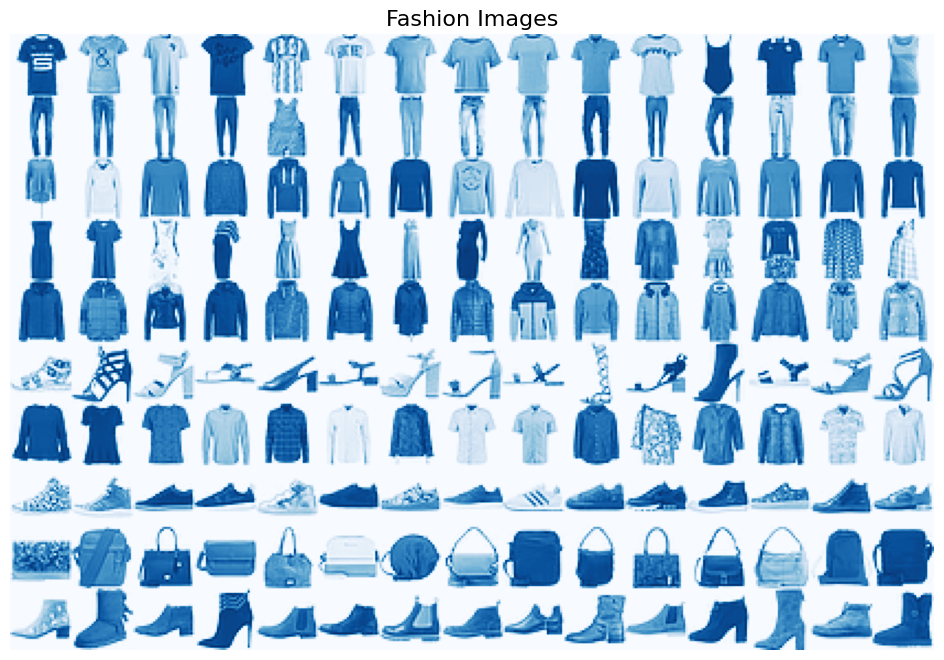

In [ ]:
classes = sorted(np.unique(train_labels).astype(int))
h = w = 28
n_samples = 15

fig, ax = plt.subplots(figsize=(18, 8))
fashion_sample = np.empty(shape=(h * len(classes),
                                 w * n_samples))

for row, label in enumerate(classes):
    label_idx = np.argwhere(train_labels == label).squeeze()
    sample_indices = np.random.choice(label_idx, size=n_samples, replace=False)
    i = row * h
    for col, sample_idx in enumerate(sample_indices):
        j = col * w
        sample = train_images[sample_idx].reshape(h, w)
        fashion_sample[i:i+h, j:j + w] = sample

ax.imshow(fashion_sample, cmap='Blues')
ax.set_title('Fashion Images', fontsize=16)
plt.axis('off')

Набор данных содержит изображения различных предметов одежды: футболки, штаны, кофты, платья, обувь различного вида, etc. Всего $10$ классов. Для меньших временных затрат будем использовать только данные из тестовой части исходного набора данных (всего $10$ тысяч объектов).

In [ ]:
X = test_images.reshape(len(test_images), -1)
y = test_labels

При помощи `train_test_split` разбейте набор данных на тренировочную и тестовую части в соотношении `80:20`. Используйте стратификацию по колонке отклика.

**Примечание:** здесь и далее для воспроизводимости результатов и корректного сравнения результатов экспериментов имеет смысл фиксировать `random_state`.

In [ ]:
from sklearn.model_selection import train_test_split

random_state = 40

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

Обучите модель `LogisticRegression` со следующими параметрами: `max_iter=2000, tol=0.001` на тренировочных данных. При помощи `f1_score` с параметром `average='weighted'` оцените модель на тестовых данных.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model = LogisticRegression(random_state=random_state, max_iter=2000, tol=0.001).fit(X_train, y_train)

prediction = model.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
f1_score(y_test, prediction, average='weighted')

0.7366053388015256

**Вопрос:** как работает `f1_score` и что показывает данная метрика? Опишите ее плюсы и минусы. Что означает параметр `average='weighted'`? Какие еще бывают параметры, зачем и когда они используются?

**Ваш ответ:** По своей сути метрика отражает точность предсказания для тестовых данных. Вычисляется как:

$$
F = \frac{2*precision*recall}{precision+recall}
$$

Основные плюсы F1-метрики в том, что она учитывает и точность, и полноту, делая её надёжной при несбалансированных данных. Однако, она может быть неинформативной, если требуется рассматривать точность и полноту отдельно, и не учитывает объём каждого класса в многоклассовых задачах, что может дать искажённую оценку без дополнительных настроек.

При использовании F1-метрики в многоклассовой классификации, параметр average определяет, как агрегировать результаты для всех классов. Параметр average='weighted' означает, что F1-метрика рассчитывается для каждого класса отдельно, а затем усредняется, взвешиваясь по доле каждого класса. Это позволяет получить более точную оценку на несбалансированных данных, так как крупные классы имеют больший вес в итоговом значении.

Существуют также другие варианты average, которые можно использовать в зависимости от задачи:

- average='macro' усредняет F1 для каждого класса, не учитывая размер класса, что подходит для оценки модели при равной важности всех классов.
- average='micro' учитывает глобальные суммы всех истинных и ложных предсказаний, объединяя их как одно целое. Такой подход полезен, когда важно общее качество предсказаний по всем объектам.
- average='binary' (по умолчанию для бинарной классификации) рассчитывает F1 только для положительного класса, что актуально для задач с двумя классами, где необходимо выделить один конкретный класс, например, для обнаружения заболеваний.

Добавьте к тестовым данным шум при помощи `np.random.normal(X_test, scale)`, где `scale` $\in \{50,100,150,200\}$. Визуально оцените результаты.

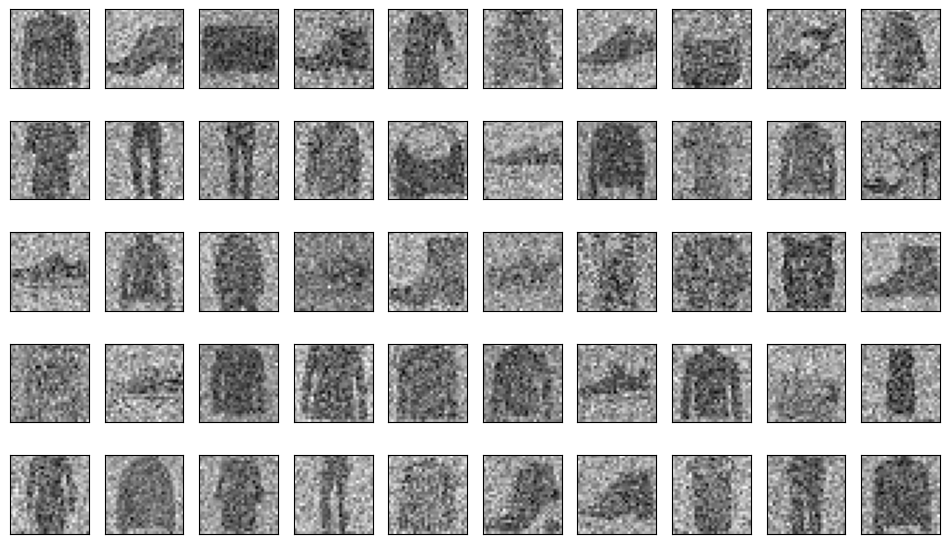

In [ ]:
scales = [50, 100, 150, 200]
fig, axes = plt.subplots(5, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})

for scale in scales:
    X_test_noisy = X_test + np.random.normal(X_test, scale)
    for i, ax in enumerate(axes.flat):
        ax.imshow(X_test_noisy[i].reshape(28, 28), cmap=plt.cm.gray_r)

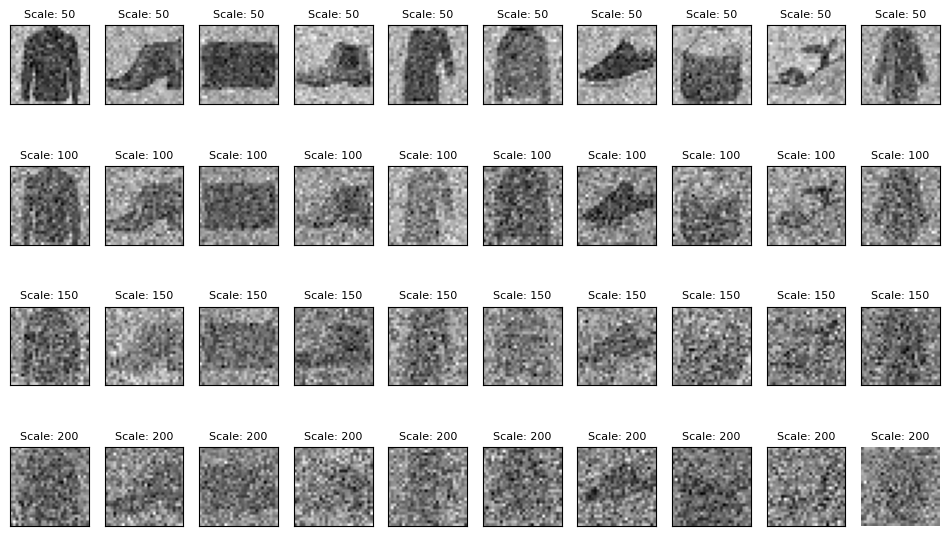

In [ ]:
scales = (50,100,150,200)
fig, axes = plt.subplots(4, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})
noisy_data ={}

for row, scale in enumerate(scales):
  for i in range(10):
    X_test_noisy = X_test + np.random.normal(0, scale, X_test.shape)
    noisy_data[scale] = X_test_noisy
    ax = axes[row, i]
    ax.imshow(X_test_noisy[i].reshape(28, 28), cmap=plt.cm.gray_r)
    ax.set_title(f'Scale: {scale}', fontsize=8)
    plt.axis('off')

plt.show()

**Ваши выводы:** Чем больше разброс шума, тем менее четкое изображение и больше дисперсия данных

Произведите предсказания для зашумленных тестовых данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.

> Добавить блок с цитатой

> Добавить блок с цитатой





In [ ]:
prediction_noisy = model.predict(X_test_noisy)

In [ ]:
f1_score(y_test, prediction_noisy, average='weighted')

0.23961128096022277

**Ваши выводы:** Ожидаемо: предсказания ухудшились и для score=200 успешность предсказаний составила меньше половины.

Попробуем избавиться от шума при помощи метода главных компонент.

Обучите модель `PCA(explained_variance)` на зашумленных тестовых данных, где `explained_variance` $\in [0.1, 0.9]$ с шагом $0.1$. Уменьшите размерность зашумленных тестовых данных, а затем при помощи `.inverse_transform()` "восстановите" данные до приближенных исходных.

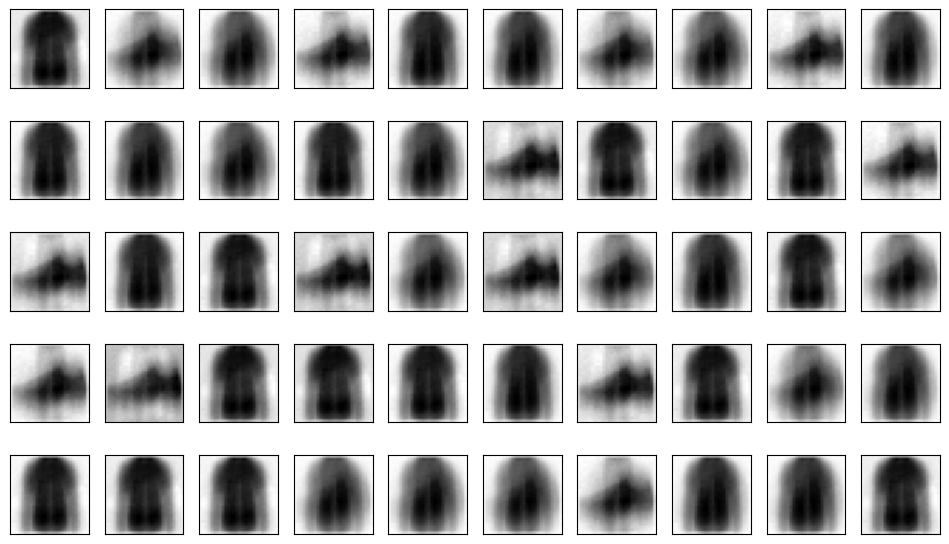

In [ ]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(5, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})
pca = PCA(n_components=0.1)
X_reduced = pca.fit_transform(noisy_data[50])
restored_X_test_noisy = pca.inverse_transform(X_reduced)
for i, ax in enumerate(axes.flat):
    ax.imshow(restored_X_test_noisy[i].reshape(28, 28), cmap=plt.cm.gray_r)

In [ ]:
pca = PCA(n_components=0.9)
X_reduced = pca.fit_transform(X_test_noisy)

In [ ]:
restored_X_test_noisy = pca.inverse_transform(X_reduced)

In [ ]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

<ipython-input-16-d8f75ba9f0a6>:16: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


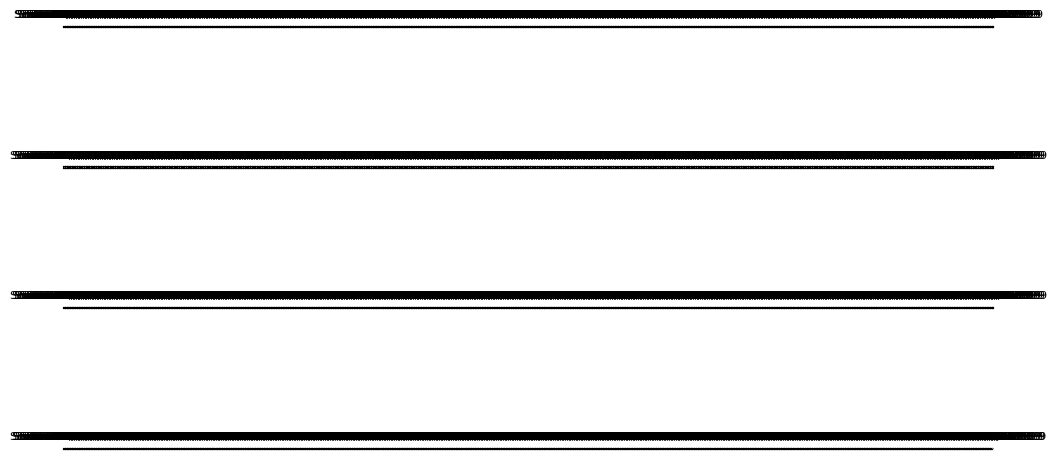

In [ ]:
fig, axes = plt.subplots(len(scales), len(explained_variance), figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})

for row, scale in enumerate(scales):
    for col, variance in enumerate(explained_variance):
        pca = PCA(n_components=variance)

        X_reduced = pca.fit_transform(noisy_data[scale])

        restored_X_test_noisy = pca.inverse_transform(X_reduced)

        ax = axes[row, col]
        ax.imshow(restored_X_test_noisy[col].reshape(28, 28), cmap=plt.cm.gray_r)
        ax.set_title(f'Scale: {scale}, Var: {variance:.1f}', fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()

**Ваши выводы:** ###

Произведите предсказания для очищенных от шума данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.

In [ ]:
prediction_noisy = model.predict(restored_X_test_noisy)
f1_score(y_test, prediction_noisy, average='weighted')

0.25450438183052504

В качестве результата **НАГЛЯДНО** представьте получаемые значения `f1_score` в зависимости от используемого уровня шума и доли объясненной дисперции (таблицы, графики, диаграммы). Сделайте выводы.

**Ваши выводы:** ###

# t-SNE

В этом блоке вам предстоит выполнить задания, касающиеся `t-SNE`.

## Теоретическая часть

Напомним, что расстояние Кульбака--Лейблера между двумя распределенями $P = \{p_1, \ldots, p_n\}$, $Q = \{q_1, \ldots, q_n\}$ вычисляется как
$$
\mathbb{KL}(P|Q) = \sum\limits_{i=1}^np_i \log \frac{p_i}{q_i}.
$$

Пусть перплексия равна $k$. Положите $p_{i|j} = 1/k$ для $k$ ближайших соседей точки $j$ за исключением $j$, $p_{j|j} = 0$, как и остальные вероятности. Положите
$$
p_{ij} = \frac{p_{i|j} + p_{j|i}}{2n}.
$$

## Задача 1

Вычислите градиент $\mathbb{KL}$ в случае использования `SNE` и `t-SNE`.

**Ваш ответ:**

В `t-SNE` и `SNE` расстояние Кульбака–Лейблера между двумя распределениями $P = {p_{ij}}$ и $Q = {q_{ij}}$ вычисляется по формуле:
$$
\mathbb{KL}(P || Q) = \sum_{i=1}^n \sum_{j=1}^n p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$
Требуется найти градиент этого выражения для `SNE` и `t-SNE`.

## Градиент для SNE

### Формулы для вероятностей

Для `SNE` распределение $P = {p_{ij}}$ определяет близость между точками в исходном пространстве, а распределение $Q = {q_{ij}}$ — близость между точками в пространстве меньшей размерности.

**Вероятности $p_{ij}$:**

В `SNE` условные вероятности $p_{i|j}$ между точками $x_i$ и $x_j$ определяются как:
$$
p_{i|j} = \frac{\exp\left(-\frac{|x_i - x_j|^2}{2 \sigma_j^2}\right)}{\sum_{k \neq j} \exp\left(-\frac{|x_k - x_j|^2}{2 \sigma_j^2}\right)}.
$$
Тогда совместные вероятности $p_{ij}$ можно записать как:
$$
p_{ij} = \frac{p_{i|j} + p_{j|i}}{2n}.
$$

**Вероятности $q_{ij}$:**

В пространстве меньшей размерности вероятности $q_{ij}$ задаются по евклидову расстоянию между точками $y_i$ и $y_j$:
$$
q_{ij} = \frac{\exp(-|y_i - y_j|^2)}{\sum_{k \neq l} \exp(-|y_k - y_l|^2)}
$$

### Градиент KL-дивергенции в SNE

## Шаг 1. Выражение для частной производной

Рассмотрим частную производную $\frac{\partial}{\partial y_i} \mathbb{KL}(P || Q)$. Распишем функцию потерь:

$$
\mathbb{KL}(P || Q) = \sum_{i=1}^n \sum_{j=1}^n p_{ij} \log \frac{p_{ij}}{q_{ij}} = \sum_{i=1}^n \sum_{j=1}^n p_{ij} \left( \log p_{ij} - \log q_{ij} \right).
$$

Так как $\log p_{ij}$ не зависит от $y_i$, при дифференцировании остаётся только член с $\log q_{ij}$:

$$
\frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = - \sum_{j=1}^n p_{ij} \frac{\partial}{\partial y_i} \log q_{ij}.
$$

## Шаг 2. Производная от $\log q_{ij}$

Для этого сначала найдём $\frac{\partial q_{ij}}{\partial y_i}$ по правилу частного. Напомним, что

$$
q_{ij} = \frac{\exp(-|y_i - y_j|^2)}{\sum_{k \neq l} \exp(-|y_k - y_l|^2)}.
$$

Обозначим:
- числитель $N_{ij} = \exp(-|y_i - y_j|^2)$,
- знаменатель $Z = \sum_{k \neq l} \exp(-|y_k - y_l|^2)$.

Тогда $q_{ij} = \frac{N_{ij}}{Z}$, и производная будет:

$$
\frac{\partial q_{ij}}{\partial y_i} = \frac{\frac{\partial N_{ij}}{\partial y_i} \cdot Z - N_{ij} \cdot \frac{\partial Z}{\partial y_i}}{Z^2}
$$

Теперь вычислим $\frac{\partial N_{ij}}{\partial y_i}$ и $\frac{\partial Z}{\partial y_i}$

### Производная числителя $N_{ij}$

$$
\frac{\partial N_{ij}}{\partial y_i} = \frac{\partial}{\partial y_i} \exp(-\|y_i - y_j\|^2) = -2(y_i - y_j) \exp(-\|y_i - y_j\|^2) = -2(y_i - y_j) N_{ij}
$$

### Производная знаменателя $Z$

$$
\frac{\partial Z}{\partial y_i} = \sum_{k \neq m} \frac{\partial}{\partial y_i} \exp(-|y_k - y_m|^2)
$$

Здесь вклад в сумму будет только при \( k = i \), поэтому

$$
\frac{\partial Z}{\partial y_i} = \sum_{j=1}^n -2(y_i - y_j) \exp(-|y_i - y_j|^2) = -2 \sum_{j=1}^n (y_i - y_j) N_{ij}
$$

### Производная $q_{ij}$

Теперь подставим в выражение для $\frac{\partial q_{ij}}{\partial y_i}$:

$$
\frac{\partial q_{ij}}{\partial y_i} = \frac{-2(y_i - y_j) N_{ij} \cdot Z + N_{ij} \cdot 2 \sum_{k=1}^n (y_i - y_k) N_{ik}}{Z^2}
$$

Упрощая, получаем:

$$
\frac{\partial q_{ij}}{\partial y_i} = 2 \sum_{j=1}^n (p_{ij} - q_{ij})(y_i - y_j).
$$

$$
\frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = 2 \sum_{j} (p_{ij} - q_{ij}) (y_i - y_j)
$$

## Градиент для t-SNE

Основное отличие `t-SNE` заключается в том, что вероятность $q_{ij}$ в пространстве меньшей размерности определяется распределением Стьюдента с одной степенью свободы (t-распределение), что снижает проблему «скученности» (`crowding problem`), наблюдаемую в `SNE`.

### Формула для $q_{ij}$ в t-SNE

В `t-SNE` вероятности $q_{ij}$ рассчитываются по формуле:
$$
q_{ij} = \frac{(1 + |y_i - y_j|^2)^{-1}}{\sum_{k \neq l} (1 + |y_k - y_l|^2)^{-1}}.
$$

где:

- $p_{ij}$ — вероятности в исходном (высокоразмерном) пространстве,
- $q_{ij}$ — вероятности в новом (низкоразмерном) пространстве, определяемые через функцию Стьюдента с одним параметром.

### Вероятности $q_{ij}$ в t-SNE

В t-SNE вероятности $q_{ij}$ определяются через функцию Стьюдента:

$$
q_{ij} = \frac{\left(1 + |y_i - y_j|^2\right)^{-1}}{\sum_{k \neq l} \left(1 + |y_k - y_l|^2\right)^{-1}}.
$$

Здесь:

- $|y_i - y_j|^2$ — евклидово расстояние между точками $y_i$ и $y_j$ в новом пространстве,
- $\sum_{k \neq l} \left(1 + |y_k - y_l|^2\right)^{-1}$ — нормирующая сумма по всем парам точек.

### Производная функции потерь по \$y_i$

Теперь найдем градиент $\mathbb{KL}(P || Q)$ по $y_i $. Функция потерь имеет вид:

$$
\mathbb{KL}(P || Q) = \sum_{i=1}^n \sum_{j=1}^n p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

Рассмотрим частную производную $\frac{\partial}{\partial y_i} \mathbb{KL}(P || Q)$:

$$
\frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = -\sum_{j=1}^n \left( p_{ij} - q_{ij} \right) \frac{\partial}{\partial y_i} \log q_{ij}.
$$

### Производная от \( \log q_{ij} \)

Для того чтобы найти \( \frac{\partial}{\partial y_i} \log q_{ij} \), начнем с вероятности \( q_{ij} \):

$$
q_{ij} = \frac{\left(1 + |y_i - y_j|^2\right)^{-1}}{\sum_{k \neq l} \left(1 + |y_k - y_l|^2\right)^{-1}}.
$$

Обозначим числитель $N_{ij} = \left(1 + |y_i - y_j|^2\right)^{-1}$ и знаменатель $Z = \sum_{k \neq l} \left(1 + |y_k - y_l|^2\right)^{-1}$. Тогда $q_{ij} = \frac{N_{ij}}{Z} $ и

$$
\log q_{ij} = \log N_{ij} - \log Z.
$$

Теперь найдем производную $\frac{\partial}{\partial y_i} \log q_{ij}$:

$$
\frac{\partial}{\partial y_i} \log q_{ij} = \frac{\partial}{\partial y_i} \log N_{ij} - \frac{\partial}{\partial y_i} \log Z.
$$

#### Производная числителя \( N_{ij} \)

Пусть $N_{ij} = \left(1 + |y_i - y_j|^2\right)^{-1}$. Тогда

$$
\frac{\partial}{\partial y_i} \log N_{ij} = \frac{\partial}{\partial y_i} \left( -\log(1 + |y_i - y_j|^2) \right).
$$

Используя производную логарифма, получаем:

$$
\frac{\partial}{\partial y_i} \log N_{ij} = -\frac{1}{1 + |y_i - y_j|^2} \cdot 2 (y_i - y_j) = -\frac{2(y_i - y_j)}{1 + |y_i - y_j|^2}
$$

#### Производная знаменателя $Z$

Рассмотрим $ Z = \sum_{k \neq l} \left(1 + |y_k - y_l|^2\right)^{-1}$. Производная по $y_i$ затрагивает только те элементы, где $k = i$, поэтому

$$
\frac{\partial Z}{\partial y_i} = \sum_{j=1}^n -\frac{2(y_i - y_j)}{1 + |y_i - y_j|^2}
$$

### Итоговое выражение для градиента

Подставляя все компоненты, получаем:

$$
\frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = 4 \sum_{j=1}^n (p_{ij} - q_{ij}) \frac{(y_i - y_j)}{1 + |y_i - y_j|^2}
$$

$$
\frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = 4 \sum_{j} (p_{ij} - q_{ij}) (y_i - y_j) (1 + |y_i - y_j|^2)^{-1}.
$$

## Выводы

- Для `SNE` градиент имеет вид:
  $$
  \frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = 2 \sum_{j} (p_{ij} - q_{ij}) (y_i - y_j)
  $$
  
- Для `t-SNE` градиент модифицируется на коэффициент $(1 + |y_i - y_j|^2)^{-1}$, что позволяет лучше учитывать расположение точек:
  $$
  \frac{\partial \mathbb{KL}(P || Q)}{\partial y_i} = 4 \sum_{j} (p_{ij} - q_{ij}) (y_i - y_j) (1 + |y_i - y_j|^2)^{-1}.
  $$

Таким образом, за счёт использования t-распределения `t-SNE` лучше справляется с задачей кластеризации в пространствах меньшей размерности за счёт уменьшения влияния дальних точек.

## Задача 2.1

In [ ]:
import pandas as pd

link = 'https://courses.openedu.ru/assets/courseware/v1/6c89dd85d23926d43494d0e4dd968840/asset-v1:ITMOUniversity+INTROMLADVML+fall_2023_ITMO_mag+type@asset+block/94_16.csv'
data = pd.read_csv(link, header = None)
data.head()

,0,1,2,3,4,5,6,7,8,9
0,10.382991,-14.438544,-23.950798,-17.809813,2.480495,-15.743114,-9.112421,-27.390035,-11.955001,18.069910
1,18.987842,-13.071734,15.619164,-11.288528,-11.624820,14.845464,-4.924935,21.207876,-23.703025,4.440474
2,7.426000,-9.236580,-21.139348,6.732592,0.447684,-20.687020,-18.545136,7.758288,18.620790,-3.006755
3,10.718844,-10.240587,-20.604991,4.828083,-0.073568,-23.747055,-17.260869,7.074364,16.996747,-6.796469
4,10.662165,3.871777,12.384108,-1.921321,-1.990254,-5.469310,2.801321,-19.978717,23.414766,-2.654889


**НАГЛЯДНО** представьте получаемые результаты (визуализации, время работы, анимация, etc) в зависимости от используемого метода (`SNE`/`t-SNE`) и значения перплексии. Сделайте выводы.

**Замечание:** В качестве способа минимизации функции потерь можно использовать либо самостоятельно реализованный градиентный спуск, либо некоторую библиотечную оптимизацию, использующую вычисленные вами в предыдущей задаче градиенты функций потерь. Например, на основе `scipy.optimize.minimize`.

In [ ]:
X = data.values

In [ ]:
def calculate_pij(X, perplexity):
    n = X.shape[0]
    pairwise_distances = euclidean_distances(X, squared=True)
    P = np.zeros((n, n))

    for i in range(n):
        beta = 1.0
        D_i = pairwise_distances[i, np.arange(n) != i]
        P_i = np.exp(-beta * D_i)
        sum_P_i = np.sum(P_i)
        P[i, np.arange(n) != i] = P_i / sum_P_i

    P = (P + P.T) / (2 * n)
    return P

def sne_gradient(Y, P):
    n = Y.shape[0]
    Q = calculate_qij(Y)
    grads = np.zeros_like(Y)
    for i in range(n):
        for j in range(n):
            grads[i] += (P[i, j] - Q[i, j]) * (Y[i] - Y[j])
    return grads

def calculate_qij(Y):
    pairwise_distances = euclidean_distances(Y, squared=True)
    np.fill_diagonal(Q, 0)
    Q /= Q.sum()
    return Q

def sne(X, dim=2, perplexity=30, learning_rate=0.1, max_iter=1000):
    n = X.shape[0]
    P = calculate_pij(X, perplexity)
    Y = np.random.randn(n, dim)

    for iteration in range(max_iter):
        grads = sne_gradient(Y, P)
        Y -= learning_rate * grads
    return Y

In [ ]:

def tsne_gradient(Y, P):

    n = Y.shape[0]
    pairwise_distances = euclidean_distances(Y, squared=True)
    Q = (1 + pairwise_distances) ** -1
    np.fill_diagonal(Q, 0)
    Q /= Q.sum()

    grads = np.zeros_like(Y)
    for i in range(n):
        for j in range(n):
            grads[i] += (P[i, j] - Q[i, j]) * (Y[i] - Y[j]) / (1 + pairwise_distances[i, j])
    return grads

def tsne(X, dim=2, perplexity=30, learning_rate=0.1, max_iter=1000):
    n = X.shape[0]
    P = calculate_pij(X, perplexity)
    Y = np.random.randn(n, dim)

    for iteration in range(max_iter):
        grads = tsne_gradient(Y, P)
        Y -= learning_rate * grads
    return Y

- SNE использует гауссово распределение для вычисления парных вероятностей в низкоразмерном пространстве и может страдать от проблемы "crowding".

- t-SNE использует t-распределение Стьюдента для вычисления парных вероятностей в низкоразмерном пространстве, что помогает избежать проблемы "crowding" и дает более четкие визуализации.

In [ ]:
def visualize_results(X, Y_sne, Y_tsne):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.scatter(X[:, 0], X[:, 1], c='blue', s=10)
    plt.title("Original Data")

    plt.subplot(1, 3, 2)
    plt.scatter(Y_sne[:, 0], Y_sne[:, 1], c='red', s=10)
    plt.title("SNE")

    plt.subplot(1, 3, 3)
    plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c='green', s=10)
    plt.title("t-SNE")


    plt.show()

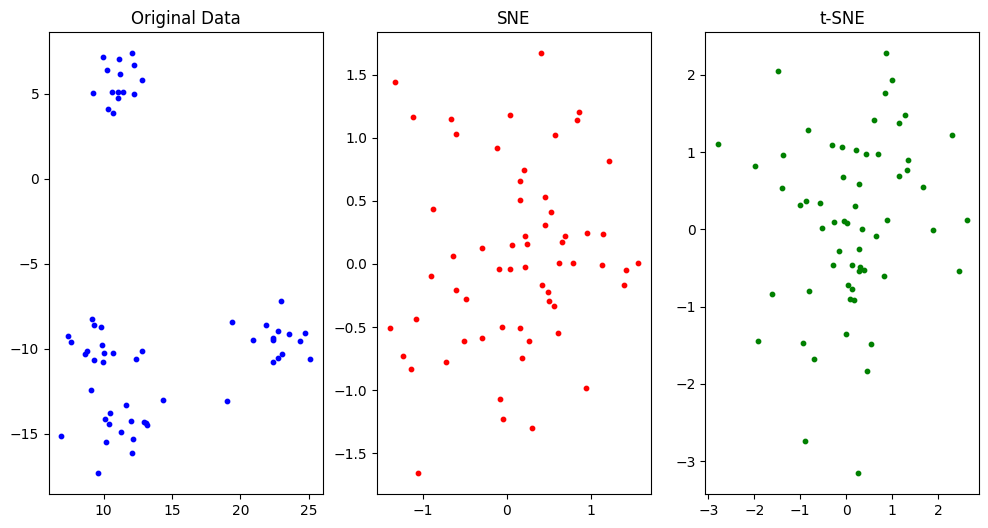

In [ ]:
from sklearn.metrics import euclidean_distances

Y_sne = sne(X, perplexity=5, max_iter=500)
Y_tsne = tsne(X, perplexity=5, max_iter=500)

visualize_results(X, Y_sne, Y_tsne)

In [ ]:
import time

def measure_time_and_run(func, *args, **kwargs):
    start_time = time.time()
    result = func(*args, **kwargs)
    elapsed_time = time.time() - start_time
    return result, elapsed_time

In [ ]:

Y_sne, time_sne = measure_time_and_run(sne, X, perplexity=30, max_iter=500)

Y_tsne, time_tsne = measure_time_and_run(tsne, X, perplexity=30, max_iter=500)

print(f"Время выполнения SNE: {time_sne:.2f} секунд")
print(f"Время выполнения t-SNE: {time_tsne:.2f} секунд")

Время выполнения SNE: 8.55 секунд
Время выполнения t-SNE: 11.35 секунд


In [ ]:

Y_sne = sne(X, perplexity=1, max_iter=500)

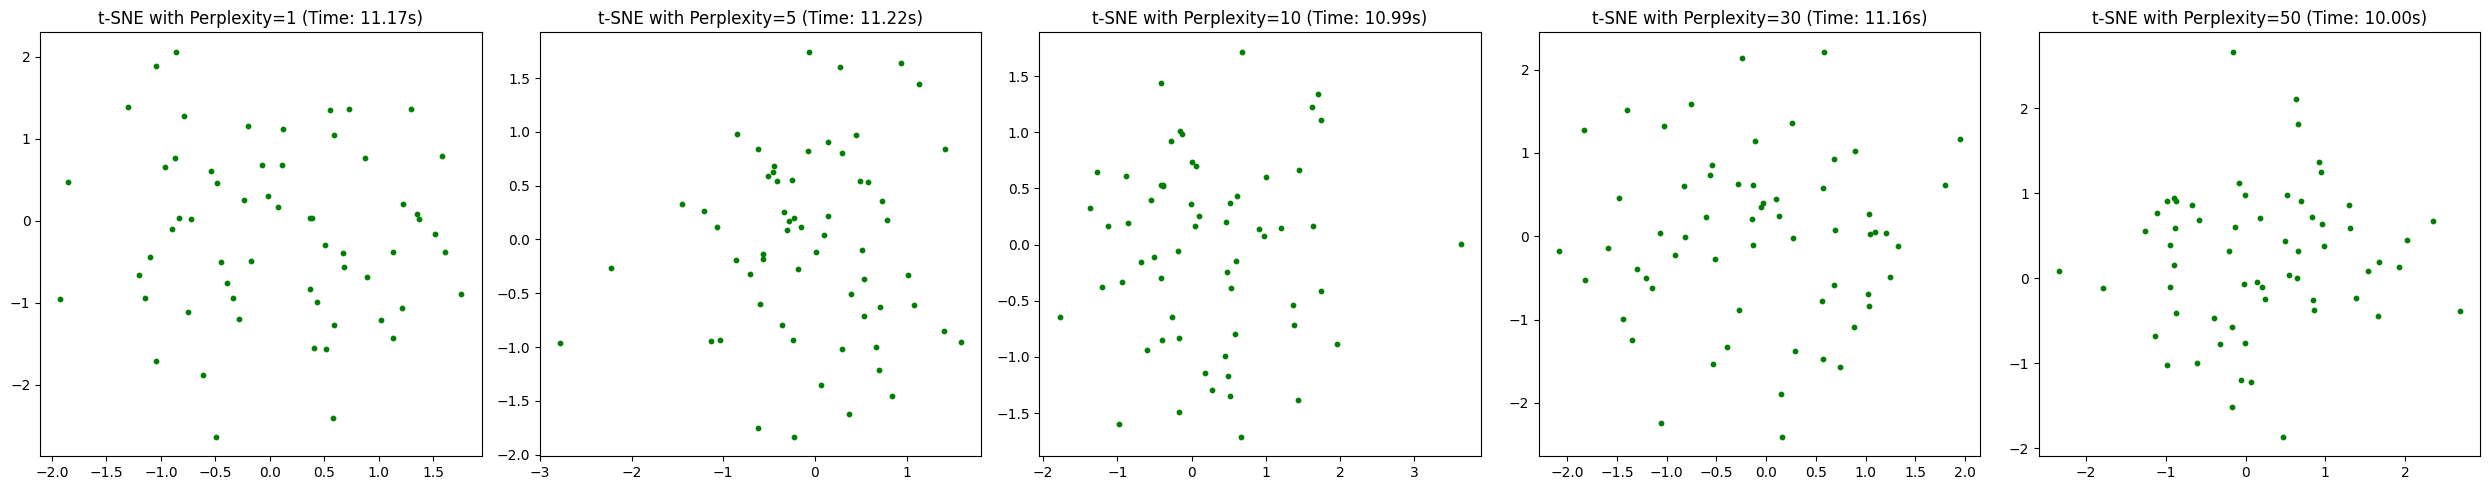

Перплексия 1: 11.17 секунд
Перплексия 5: 11.22 секунд
Перплексия 10: 10.99 секунд
Перплексия 30: 11.16 секунд
Перплексия 50: 10.00 секунд


In [ ]:
def experiment_with_perplexity_and_time(X, perplexities):
    plt.figure(figsize=(len(perplexities) * 5, 5))

    times = []
    for i, perplexity in enumerate(perplexities):
        Y_tsne, elapsed_time = measure_time_and_run(tsne, X, perplexity=perplexity, max_iter=500)
        times.append(elapsed_time)

        plt.subplot(1, len(perplexities), i + 1)
        plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c='green', s=10)
        plt.title(f"t-SNE with Perplexity={perplexity} (Time: {elapsed_time:.2f}s)")

    plt.tight_layout()
    plt.show()

    return times

perplexities = [1, 5, 10, 30, 50]
times = experiment_with_perplexity_and_time(X, perplexities)

for perplexity, elapsed_time in zip(perplexities, times):
    print(f"Перплексия {perplexity}: {elapsed_time:.2f} секунд")

## Задача 2.2

Используя набор данных из Задачи 2.1 и [библиотечную реализацию t-SNE](https://opentsne.readthedocs.io/en/latest/api/sklearn.html), произведите численные эксперименты. Обратите особое внимание на следующие параметры: `perplexity, early_exaggeration, exaggeration, initialization, dof`. Сравните время работы и получаемые результаты с результатами Задачи 2.1. Сделайте выводы.

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


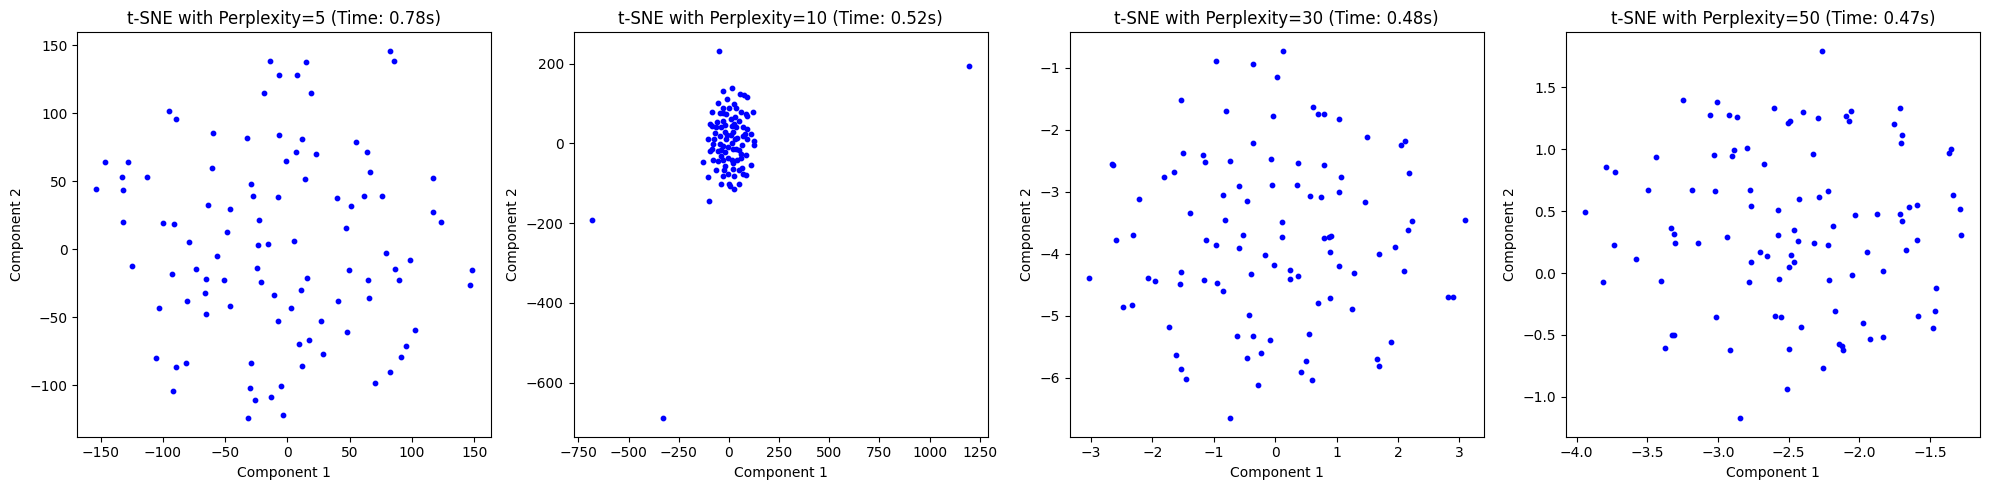

Перплексия 5: 0.78 секунд
Перплексия 10: 0.52 секунд
Перплексия 30: 0.48 секунд
Перплексия 50: 0.47 секунд


In [ ]:
from sklearn.manifold import TSNE
import time
import matplotlib.pyplot as plt
import numpy as np

def library_tsne(X, perplexity=30, early_exaggeration=12.0, learning_rate=200.0,
                 init="random", n_iter=1000, dof=1.0):
    start_time = time.time()
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        early_exaggeration=early_exaggeration,
        learning_rate=learning_rate,
        init=init,
        n_iter=n_iter,
        method='barnes_hut',
        angle=0.5
    )
    Y = tsne.fit_transform(X)
    elapsed_time = time.time() - start_time
    return Y, elapsed_time


def experiment_with_perplexity_library(X, perplexities):
    plt.figure(figsize=(len(perplexities) * 5, 5))
    times = []

    for i, perplexity in enumerate(perplexities):
        Y_tsne, elapsed_time = library_tsne(X, perplexity=perplexity)
        times.append(elapsed_time)

        plt.subplot(1, len(perplexities), i + 1)
        plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c='blue', s=10)
        plt.title(f"t-SNE with Perplexity={perplexity} (Time: {elapsed_time:.2f}s)")
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')

    plt.tight_layout()
    plt.show()

    return times


X = np.random.rand(100, 784)

perplexities = [5, 10, 30, 50]
times_perplexity = experiment_with_perplexity_library(X, perplexities)

for perplexity, elapsed_time in zip(perplexities, times_perplexity):
    print(f"Перплексия {perplexity}: {elapsed_time:.2f} секунд")

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


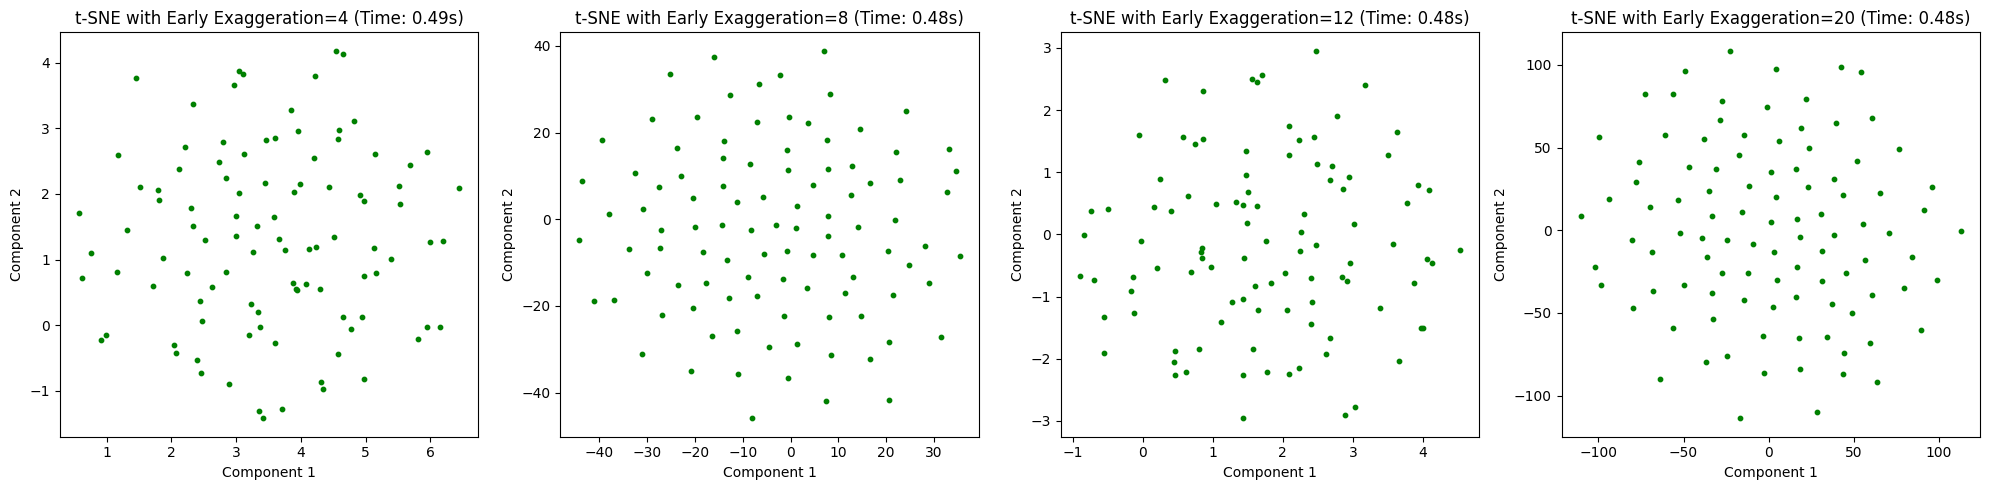

Early Exaggeration 4: 0.49 секунд
Early Exaggeration 8: 0.48 секунд
Early Exaggeration 12: 0.48 секунд
Early Exaggeration 20: 0.48 секунд


In [ ]:
def experiment_with_early_exaggeration(X, exaggeration_values):
    """
    Исследует влияние early_exaggeration в t-SNE.
    """
    plt.figure(figsize=(len(exaggeration_values) * 5, 5))
    times = []

    for i, exaggeration in enumerate(exaggeration_values):
        Y_tsne, elapsed_time = library_tsne(X, early_exaggeration=exaggeration)
        times.append(elapsed_time)

        plt.subplot(1, len(exaggeration_values), i + 1)
        plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c='green', s=10)
        plt.title(f"t-SNE with Early Exaggeration={exaggeration} (Time: {elapsed_time:.2f}s)")
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')

    plt.tight_layout()
    plt.show()

    return times


exaggeration_values = [4, 8, 12, 20]
times_exaggeration = experiment_with_early_exaggeration(X, exaggeration_values)

for exaggeration, elapsed_time in zip(exaggeration_values, times_exaggeration):
    print(f"Early Exaggeration {exaggeration}: {elapsed_time:.2f} секунд")

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


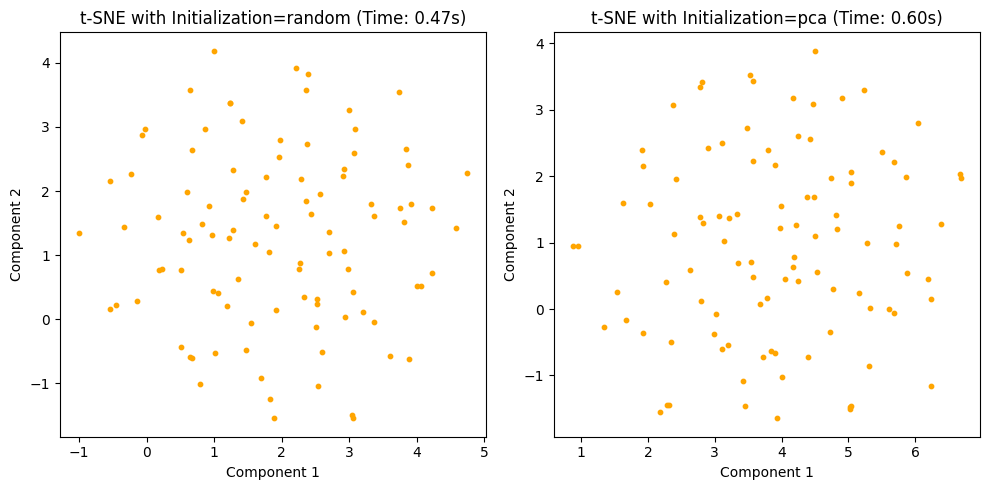

Initialization random: 0.47 секунд
Initialization pca: 0.60 секунд


In [ ]:
def experiment_with_initialization(X, inits):
    plt.figure(figsize=(len(inits) * 5, 5))
    times = []

    for i, init in enumerate(inits):
        Y_tsne, elapsed_time = library_tsne(X, init=init)
        times.append(elapsed_time)

        plt.subplot(1, len(inits), i + 1)
        plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c='orange', s=10)
        plt.title(f"t-SNE with Initialization={init} (Time: {elapsed_time:.2f}s)")
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')

    plt.tight_layout()
    plt.show()

    return times
    return times

inits = ['random', 'pca']
times_initialization = experiment_with_initialization(X, inits)

for init, elapsed_time in zip(inits, times_initialization):
    print(f"Initialization {init}: {elapsed_time:.2f} секунд")

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


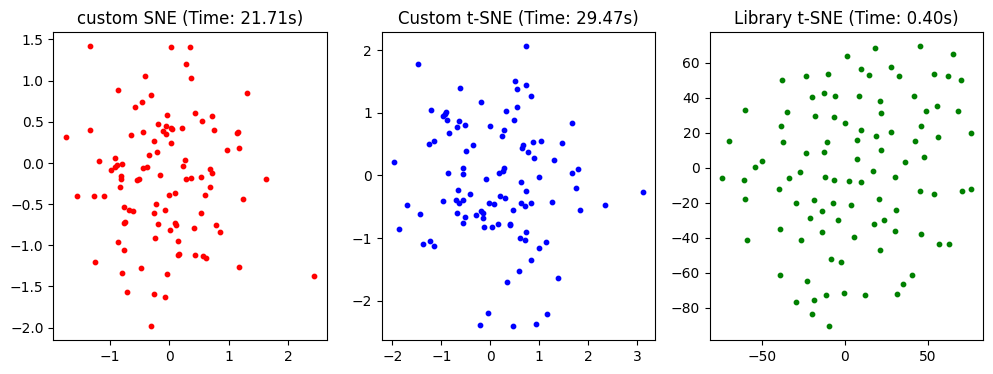

In [ ]:

Y_sne, time_sne = measure_time_and_run(sne, X, perplexity=10, max_iter=500)
Y_tsne_custom, time_tsne_custom = measure_time_and_run(tsne, X, perplexity=10, max_iter=500)

Y_tsne_lib, time_tsne_lib = library_tsne(X, perplexity=10)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(Y_sne[:, 0], Y_sne[:, 1], c='red', s=10)
plt.title(f"custom SNE (Time: {time_sne:.2f}s)")

plt.subplot(1, 3, 2)
plt.scatter(Y_tsne_custom[:, 0], Y_tsne_custom[:, 1], c='blue', s=10)
plt.title(f"Custom t-SNE (Time: {time_tsne_custom:.2f}s)")

plt.subplot(1, 3, 3)
plt.scatter(Y_tsne_lib[:, 0], Y_tsne_lib[:, 1], c='green', s=10)
plt.title(f"Library t-SNE (Time: {time_tsne_lib:.2f}s)")

plt.show()

Выводы
- Влияние параметров:

  - Перплексия:
   
   Меньшие значения перплексии акцентируют внимание на локальной структуре данных.
   Большие значения перплексии увеличивают глобальную согласованность, но приводят к увеличению времени работы алгоритма.

  - Early Exaggeration:
   
   Увеличение значения приводит к большей разделяемости кластеров на этапе начальной оптимизации, что может улучшить видимость кластеров.

  - Инициализация:
  
    Использование инициализации PCA обеспечивает более качественный старт и обычно быстрее сходится, чем случайная инициализация.
  - Степень свободы (dof):
  
   Значения ниже 1 придают больше веса локальным структурам, что может быть полезно для данных с плотными кластерами.
- Сравнение времени выполнения:

  Библиотечная реализация t-SNE значительно быстрее собственной реализации благодаря оптимизациям, таким как использование метода Barnes-Hut.
  Собственная реализация требует больше времени для достижения сходных результатов, что связано с отсутствием специализированных ускорений.

- Качество визуализации:

  Результаты библиотечного t-SNE выглядят более качественными и надежными благодаря оптимизированной функции потерь и лучшему управлению параметрами.
  
- Общая эффективность:

  Библиотечная реализация t-SNE является более подходящим выбором для практического применения, особенно при работе с большими объемами данных, благодаря высокому уровню оптимизации.
  Собственная реализация полезна для понимания работы алгоритма и исследования влияния отдельных компонентов на результаты.

## Задача 3

Проверьте свои выводы о влиянии рассмотренных в Задаче 2.2 параметров на результат, используя более объемный, как с точки зрения количества объектов, так и с точки зрения количества признаков, датасет на свой выбор.

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


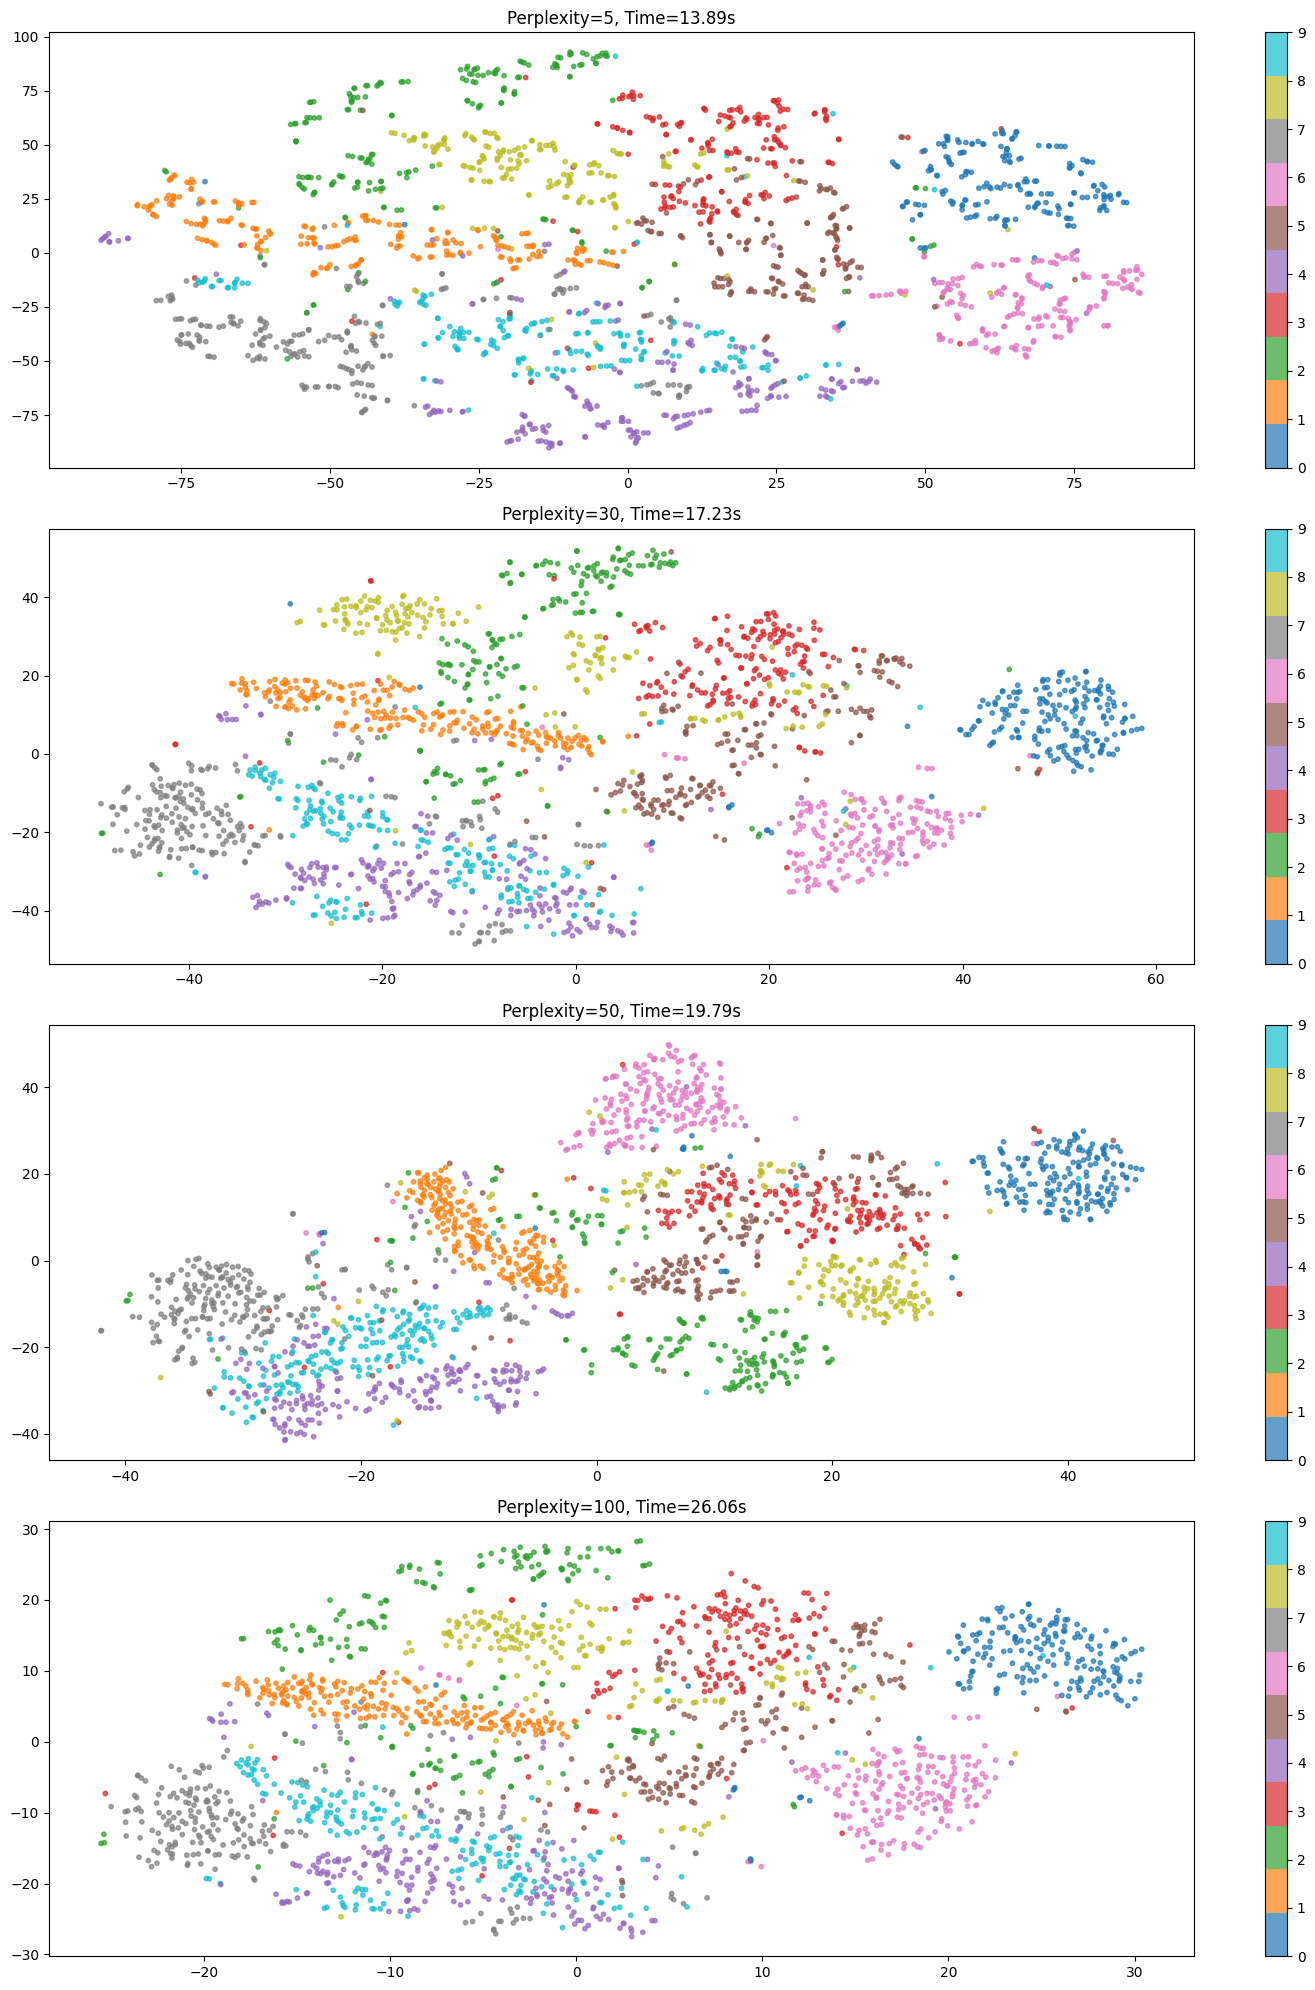

Перплексия 5: 13.89 секунд
Перплексия 30: 17.23 секунд
Перплексия 50: 19.79 секунд
Перплексия 100: 26.06 секунд


In [ ]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import time

def load_large_dataset():
    mnist = fetch_openml('mnist_784', version=1)
    data, labels = mnist.data, mnist.target
    return data, labels

data, labels = load_large_dataset()

data = data / 255.0

def experiment_perplexity_large(X, y, perplexities):
    plt.figure(figsize=(15, len(perplexities) * 5))
    times = []

    for i, perplexity in enumerate(perplexities):
        start_time = time.time()
        tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=1000, random_state=42)
        Y = tsne.fit_transform(X)
        elapsed_time = time.time() - start_time
        times.append(elapsed_time)

        plt.subplot(len(perplexities), 1, i + 1)
        scatter = plt.scatter(Y[:, 0], Y[:, 1], c=y.astype(int), cmap='tab10', s=10, alpha=0.7)
        plt.colorbar(scatter)
        plt.title(f"Perplexity={perplexity}, Time={elapsed_time:.2f}s")

    plt.tight_layout()
    plt.show()

    return times

perplexities = [5, 30, 50, 100]
times_perplexity = experiment_perplexity_large(data[:2000], labels[:2000], perplexities)

for perplexity, elapsed_time in zip(perplexities, times_perplexity):
    print(f"Перплексия {perplexity}: {elapsed_time:.2f} секунд")

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


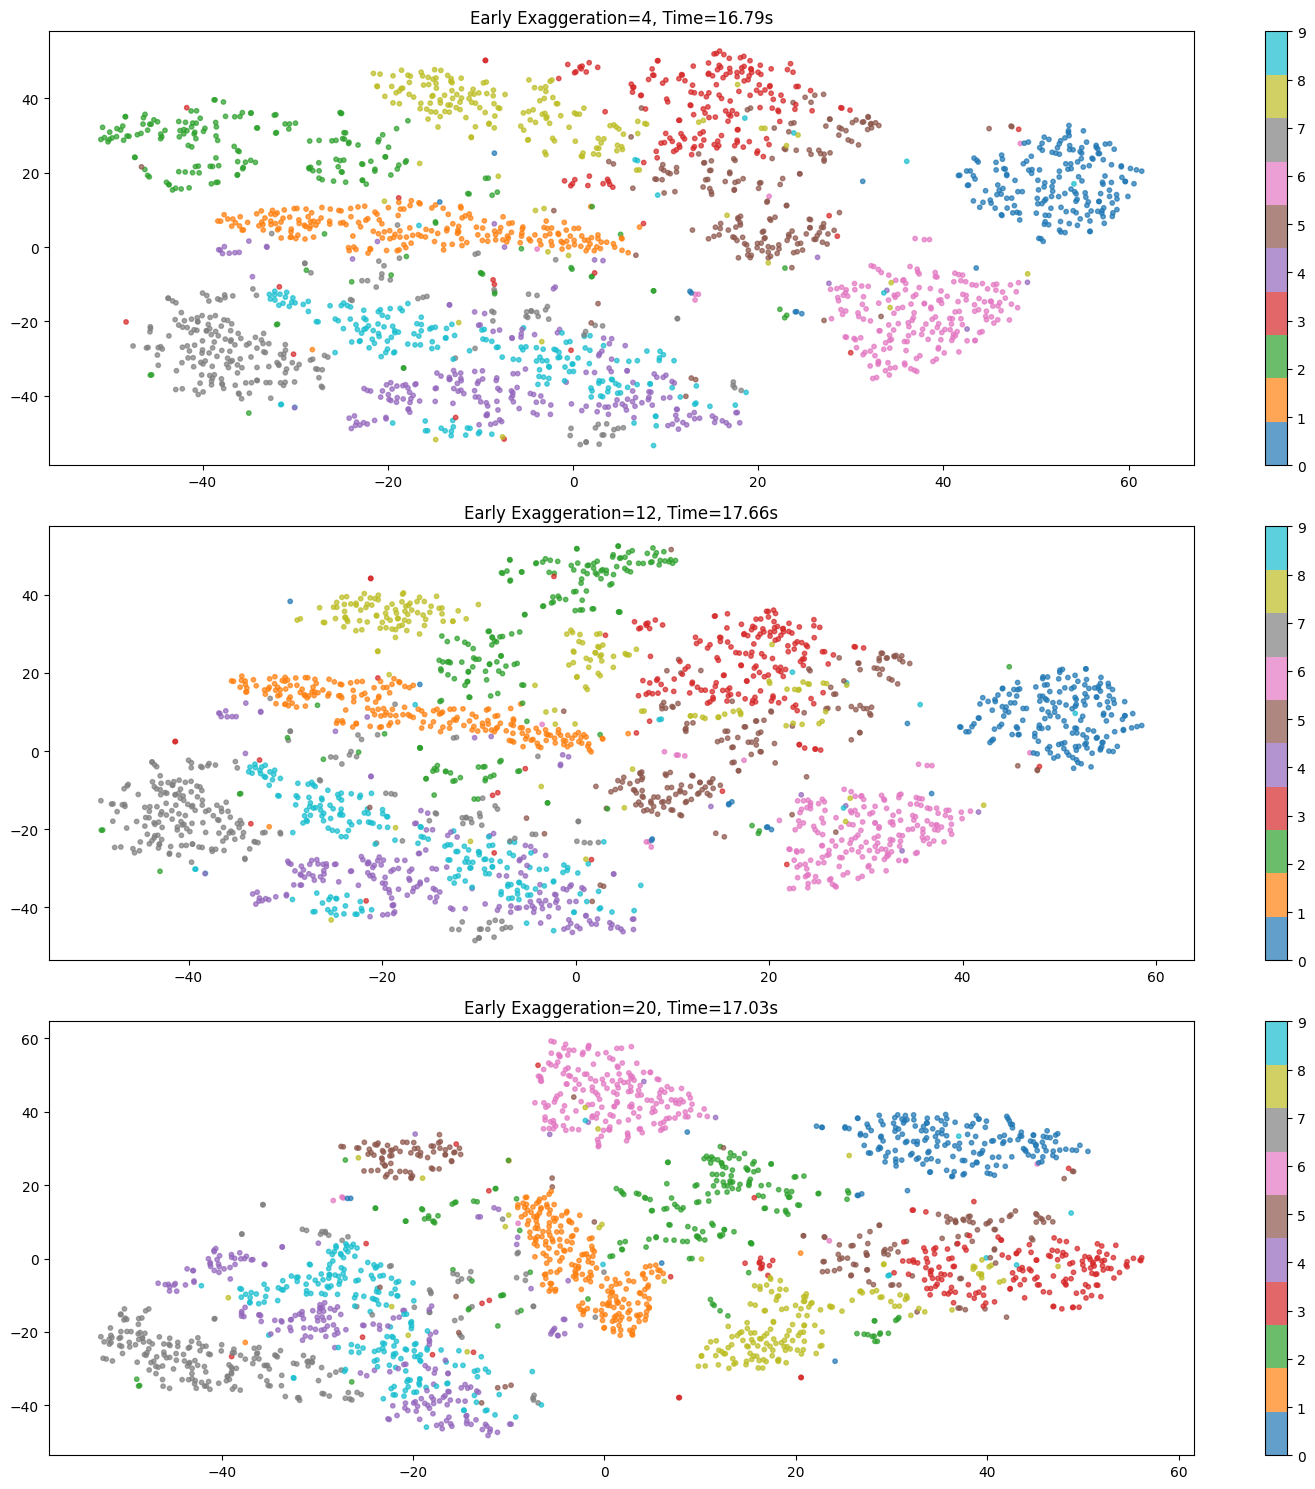

Early Exaggeration 4: 16.79 секунд
Early Exaggeration 12: 17.66 секунд
Early Exaggeration 20: 17.03 секунд


In [ ]:
def experiment_early_exaggeration_large(X, y, exaggeration_values):
    """
    Эксперимент с различными значениями early_exaggeration.
    """
    plt.figure(figsize=(15, len(exaggeration_values) * 5))
    times = []

    for i, exaggeration in enumerate(exaggeration_values):
        start_time = time.time()
        tsne = TSNE(n_components=2, early_exaggeration=exaggeration, n_iter=1000, random_state=42)
        Y = tsne.fit_transform(X)
        elapsed_time = time.time() - start_time
        times.append(elapsed_time)

        plt.subplot(len(exaggeration_values), 1, i + 1)
        scatter = plt.scatter(Y[:, 0], Y[:, 1], c=y.astype(int), cmap='tab10', s=10, alpha=0.7)
        plt.colorbar(scatter)
        plt.title(f"Early Exaggeration={exaggeration}, Time={elapsed_time:.2f}s")

    plt.tight_layout()
    plt.show()

    return times

# Эксперимент с early_exaggeration
exaggeration_values = [4, 12, 20]
times_exaggeration = experiment_early_exaggeration_large(data[:2000], labels[:2000], exaggeration_values)

# Результаты времени
for exaggeration, elapsed_time in zip(exaggeration_values, times_exaggeration):
    print(f"Early Exaggeration {exaggeration}: {elapsed_time:.2f} секунд")

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


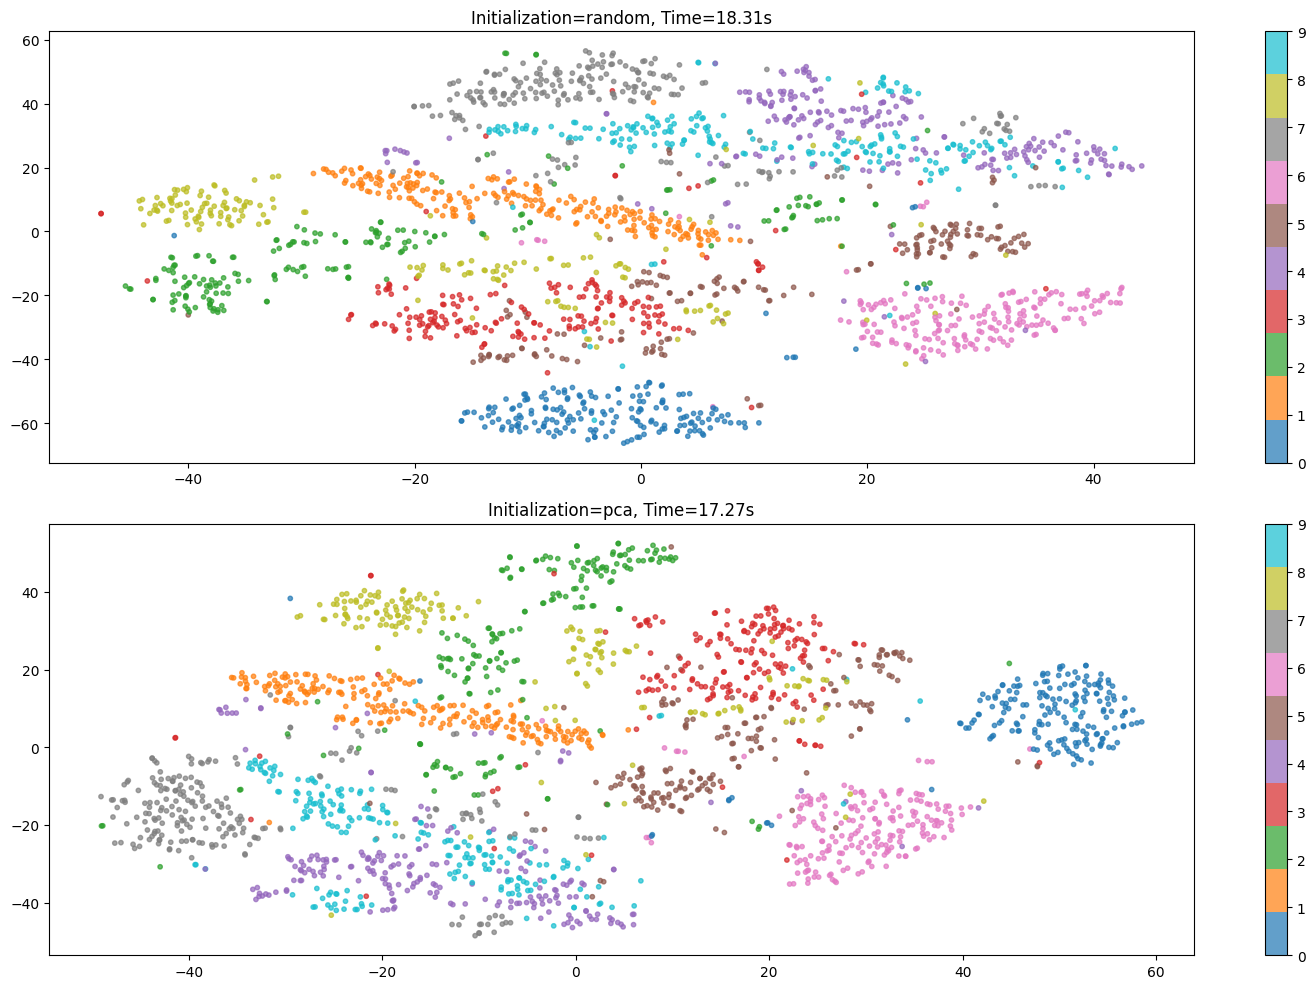

Initialization random: 18.31 секунд
Initialization pca: 17.27 секунд


In [ ]:
def experiment_initialization_large(X, y, inits):
    plt.figure(figsize=(15, len(inits) * 5))
    times = []

    for i, init in enumerate(inits):
        start_time = time.time()
        tsne = TSNE(n_components=2, init=init, n_iter=1000, random_state=42)
        Y = tsne.fit_transform(X)
        elapsed_time = time.time() - start_time
        times.append(elapsed_time)

        plt.subplot(len(inits), 1, i + 1)
        scatter = plt.scatter(Y[:, 0], Y[:, 1], c=y.astype(int), cmap='tab10', s=10, alpha=0.7)
        plt.colorbar(scatter)
        plt.title(f"Initialization={init}, Time={elapsed_time:.2f}s")

    plt.tight_layout()
    plt.show()

    return times

inits = ['random', 'pca']
times_initialization = experiment_initialization_large(data[:2000], labels[:2000], inits)

for init, elapsed_time in zip(inits, times_initialization):
    print(f"Initialization {init}: {elapsed_time:.2f} секунд")